In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.impute import KNNImputer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE


count     590.000000
mean       71.103390
std       241.850565
min         0.000000
25%         2.000000
50%         6.000000
75%         9.000000
max      1429.000000
dtype: float64
----------------------------------------------------------------------------------------------------


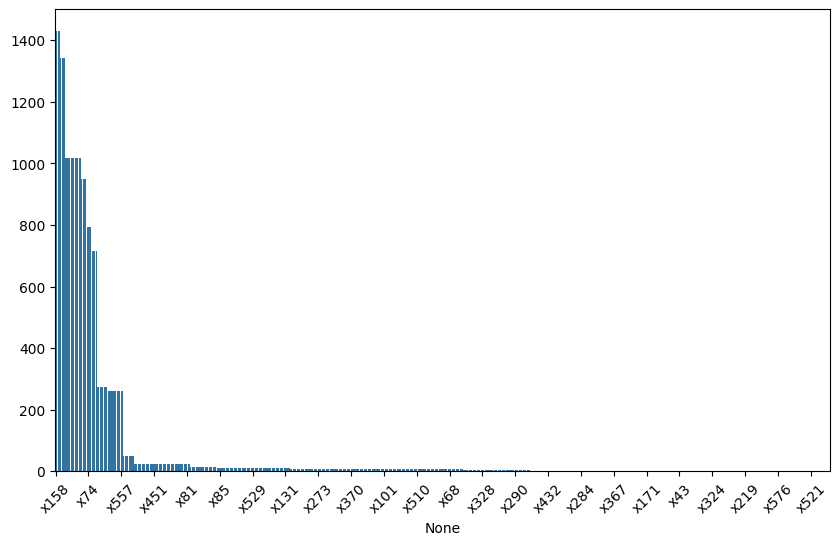

In [2]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum().sort_values(ascending=False)
print(na_counts.describe().T)
print('--'*50)
plt.figure(figsize=(10, 6))
sns.barplot(x=na_counts.index, y=na_counts.values)
plt.xticks(range(0, len(na_counts), 25), na_counts.index[::25], rotation=45)
plt.show()

c:\Users\USER\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\USER\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


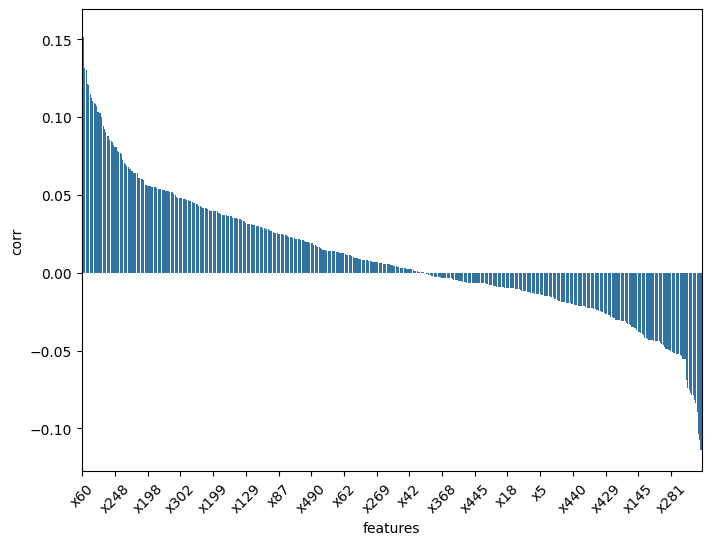

In [3]:
xy_corr = X.corrwith(y).dropna().sort_values(ascending=False)
xy_corr_df = xy_corr.reset_index()
xy_corr_df.columns = ['features', 'corr']
plt.figure(figsize=(8, 6))
sns.barplot(data=xy_corr_df, x='features', y='corr')
plt.xticks(range(0, len(xy_corr), 25), xy_corr.index[::25], rotation=45)
plt.show()

In [4]:
X.count()

x1      1561
x2      1560
x3      1553
x4      1553
x5      1553
        ... 
x586    1566
x587    1566
x588    1566
x589    1566
x590    1566
Length: 590, dtype: int64

In [ ]:
col_val_counts = X.count()